## Cél

Ez a notebook a `target` tábla éves viselkedését vizsgálja, azzal a gyakorlati kérdéssel, hogy a modellfejlesztéshez és a 2026-os kalibrációhoz mennyire használható együtt a teljes múltbeli időszak.

A fókusz a jelenlegi long runtime targeten van: `long_mfe_fw60`. Ez az a target, amelyhez a mostani runtime modell konfiguráció kapcsolódik. A vizsgálat kiterjed az időbeli alakulásra, éves range-ekre, eloszlások közötti hasonlóságra, valamint a havi és negyedéves szezonális mintákra.

**Kapcsolódó dokumentáció:**
- Módszertan: `_doc_/3000_targets.md`
- Kód-dokumentáció: `_doc_/3100_sync_targets.md`

**Asset:** SOLUSDT | **Granularitás:** 1m | **Dátum:** 2026-06-20


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

_root = Path.cwd()
if _root.name == "_doc_":
    _root = _root.parent

sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))

from analyst.table_formatting import display_analysis_table

helper_path = _root / "analyst" / "3200_target_yearly_analysis.py"
spec = importlib.util.spec_from_file_location("target_yearly_analysis_3200", helper_path)
h = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = h
assert spec.loader is not None
spec.loader.exec_module(h)

runtime_cfg = json.loads((_root / "config/env.json").read_text(encoding="utf-8"))
models_cfg = json.loads((_root / "config/models.json").read_text(encoding="utf-8"))
active_model_id = runtime_cfg["runtime"]["model_id"]
active_target = models_cfg["models"].get(active_model_id, {}).get("target_name", "long_mfe_fw60")

CQ_COLORS = {
    "blue": "#1696d2",
    "black": "#000000",
    "gray_dark": "#353535",
    "gray": "#696969",
    "gray_light": "#d2d2d2",
    "yellow": "#fdbf11",
    "orange": "#f15a24",
    "red": "#ec008b",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"], CQ_COLORS["yellow"], CQ_COLORS["orange"],
    CQ_COLORS["gray"], CQ_COLORS["red"],
]

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": CQ_COLORS["gray"],
        "axes.labelcolor": CQ_COLORS["gray_dark"],
        "xtick.color": CQ_COLORS["gray_dark"],
        "ytick.color": CQ_COLORS["gray_dark"],
        "grid.color": CQ_COLORS["gray_light"],
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    },
)
sns.set_palette(CQ_SEQUENCE)

df = h.load_target_frame(active_target)
valid_df = df.dropna(subset=[active_target]).copy()
coverage_df = h.coverage_summary(df, active_target)
yearly_df = h.yearly_stats(df, active_target)
monthly_df = h.monthly_summary(df, active_target)
quarterly_df = h.quarterly_summary(df, active_target)
distance_df = h.pairwise_distribution_distance(df, active_target)
same_span_df = h.same_span_comparison(df, active_target)
profile_corr_df = h.monthly_profile_correlation(df, active_target)
monthly_rel_df, monthly_rel_summary_df = h.relative_seasonality(df, active_target, "month")
quarterly_rel_df, quarterly_rel_summary_df = h.relative_seasonality(df, active_target, "quarter")
cutoff = h.year_cutoff_for_latest(valid_df)
latest_year = int(valid_df["year"].max())
hourly_plot_df = valid_df.groupby("year", group_keys=False).apply(lambda g: g.iloc[::60]).reset_index(drop=True)

display(Markdown(
    f"**Scope:** aktív modell = `{active_model_id}`, target = `{active_target}`. "
    f"A legfrissebb elérhető valid target-időpont: `{cutoff.max_timestamp:%Y-%m-%d %H:%M}`."
))


C:\Users\eross\AppData\Local\Temp\ipykernel_10028\2626904543.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_plot_df = valid_df.groupby("year", group_keys=False).apply(lambda g: g.iloc[::60]).reset_index(drop=True)


**Scope:** aktív modell = `lgbm_solusdt_l_fw60_q90_local_v4`, target = `long_mfe_fw60`. A legfrissebb elérhető valid target-időpont: `2026-06-14 11:00`.

## Adatfedettség

**Mi ez.** A `target` tábla éves lefedettsége és a valid target sorok aránya.

**Forrás.** `target` tábla, `open_time`, `long_mfe_fw60` oszlopok.

**Értelmezés.** Itt látszik, hogy mely évek teljesek és melyek csonkák. Ez különösen fontos a 2026-os összevetésnél, mert a csonka évet csak azonos időablakú korábbi részidőszakokkal szabad fair módon hasonlítani.


In [2]:
#| label: tbl-target-coverage-by-year
#| tbl-cap: "A target tábla éves lefedettsége és valid target aránya"

display_analysis_table(coverage_df)

partial_years = coverage_df.loc[
    (coverage_df["min_time"].dt.month != 1)
    | (coverage_df["min_time"].dt.day != 1)
    | (coverage_df["max_time"].dt.month != 12)
    | (coverage_df["max_time"].dt.day != 31),
    "year",
].astype(int).tolist()
display(Markdown(
    f"**Értelmezés:** a teljes éves blokkok 2021-2025 között állnak rendelkezésre. "
    f"A csonka évek: {partial_years}. A 2026-os valid target-időszak vége: "
    f"`{cutoff.max_timestamp:%Y-%m-%d}`."
))


year,rows,valid_rows,min_time,max_time,valid_rate
2020,156540,156540,2020-09-14 07:00:00,2020-12-31 23:59:00,100.00%
2021,525600,525600,2021-01-01 00:00:00,2021-12-31 23:59:00,100.00%
2022,525600,525600,2022-01-01 00:00:00,2022-12-31 23:59:00,100.00%
2023,525600,525600,2023-01-01 00:00:00,2023-12-31 23:59:00,100.00%
2024,527040,527040,2024-01-01 00:00:00,2024-12-31 23:59:00,100.00%
2025,525600,525600,2025-01-01 00:00:00,2025-12-31 23:59:00,100.00%
2026,236881,236821,2026-01-01 00:00:00,2026-06-14 12:00:00,99.97%


**Értelmezés:** a teljes éves blokkok 2021-2025 között állnak rendelkezésre. A csonka évek: [2020, 2026]. A 2026-os valid target-időszak vége: `2026-06-14`.

## Időbeli alakulás

**Mi ez.** A target havi átlagának teljes idősoros képe.

**Forrás.** `target` tábla, `long_mfe_fw60`, havi aggregáció.

**Értelmezés.** Ha a target szintje évről évre lecsúszik vagy rezsimek között látványosan eltér, akkor a teljes history egyben való felhasználása csak óvatosan indokolható.


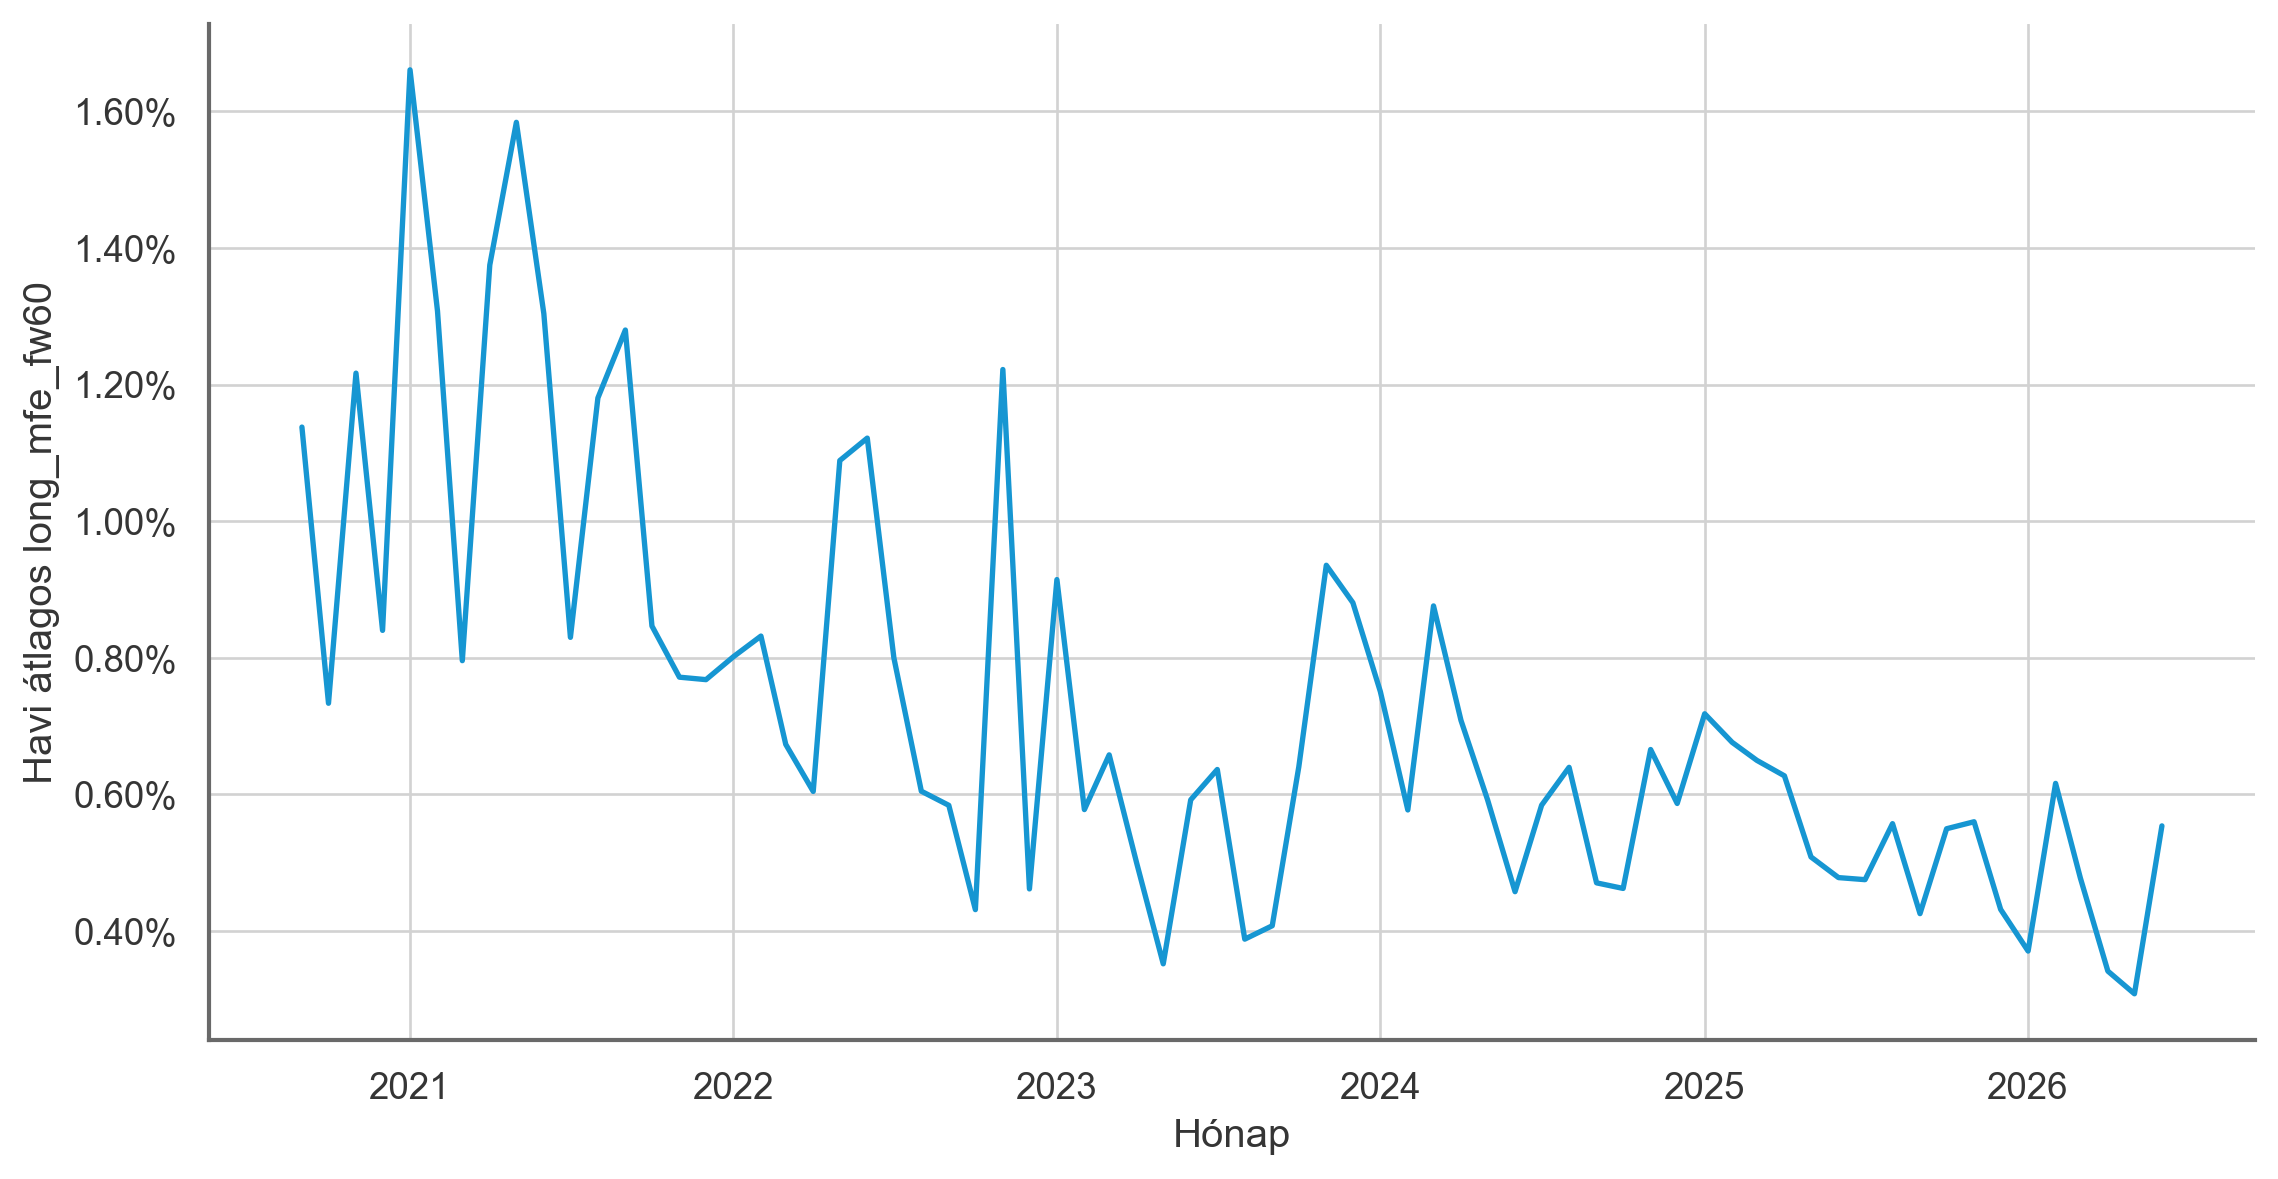

**Értelmezés:** a teljes idősor lefelé csúszó rezsimet mutat. A legkorábbi éves átlag `0.96%`, míg a legfrissebb `0.43%`.

In [3]:
#| label: fig-target-monthly-mean-over-time
#| fig-cap: "A havi átlagos long target alakulása a teljes időszakon"
#| fig-alt: "Line chart showing monthly average long target over time from 2020 to 2026."

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = monthly_df.sort_values("year_month").copy()
sns.lineplot(data=plot_df, x="year_month", y="mean", ax=ax, color=CQ_COLORS["blue"], linewidth=1.6)
ax.set_xlabel("Hónap")
ax.set_ylabel("Havi átlagos long_mfe_fw60")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=2))
plt.show()

first_mean = float(yearly_df.iloc[0]["mean"])
last_mean = float(yearly_df.iloc[-1]["mean"])
display(Markdown(
    f"**Értelmezés:** a teljes idősor lefelé csúszó rezsimet mutat. "
    f"A legkorábbi éves átlag `{first_mean:.2%}`, míg a legfrissebb `{last_mean:.2%}`."
))


## Éves range és szórás

**Mi ez.** Éves szintű átlag, szórás és fontos kvantilisek.

**Forrás.** `target` tábla, `long_mfe_fw60` éves aggregációi.

**Értelmezés.** Ez válaszolja meg közvetlenül, hogy évenként mennyire más a target szintje és range-e.


In [4]:
#| label: tbl-target-yearly-stats
#| tbl-cap: "Éves target statisztikák: átlag, szórás és kvantilisek"

display_analysis_table(yearly_df)

best_year = int(yearly_df.sort_values("mean", ascending=False).iloc[0]["year"])
worst_year = int(yearly_df.sort_values("mean", ascending=True).iloc[0]["year"])
display(Markdown(
    f"**Értelmezés:** az éves átlag alapján a legerősebb év `{best_year}`, a leggyengébb `{worst_year}`. "
    "Ez önmagában már arra utal, hogy a target nem évesen homogén."
))


year,count,mean,std,min,median,max,q01,q05,q25,q75,q95,q99
2020,156540,0.010,0.012,-0.032,0.006,0.136,-0.003,-0.000,0.002,0.013,0.032,0.055
2021,525600,0.011,0.014,-0.047,0.007,0.392,-0.003,-0.000,0.003,0.015,0.037,0.066
2022,525600,0.008,0.011,-0.067,0.005,0.299,-0.002,-0.000,0.002,0.010,0.025,0.049
2023,525600,0.006,0.008,-0.065,0.004,0.194,-0.001,-0.000,0.002,0.008,0.020,0.038
2024,527040,0.006,0.007,-0.048,0.004,0.166,-0.001,-0.000,0.002,0.008,0.019,0.033
2025,525600,0.006,0.007,-0.023,0.004,0.269,-0.001,-0.000,0.002,0.007,0.017,0.030
2026,236821,0.004,0.005,-0.017,0.003,0.134,-0.001,-0.000,0.001,0.006,0.014,0.025


**Értelmezés:** az éves átlag alapján a legerősebb év `2021`, a leggyengébb `2026`. Ez önmagában már arra utal, hogy a target nem évesen homogén.

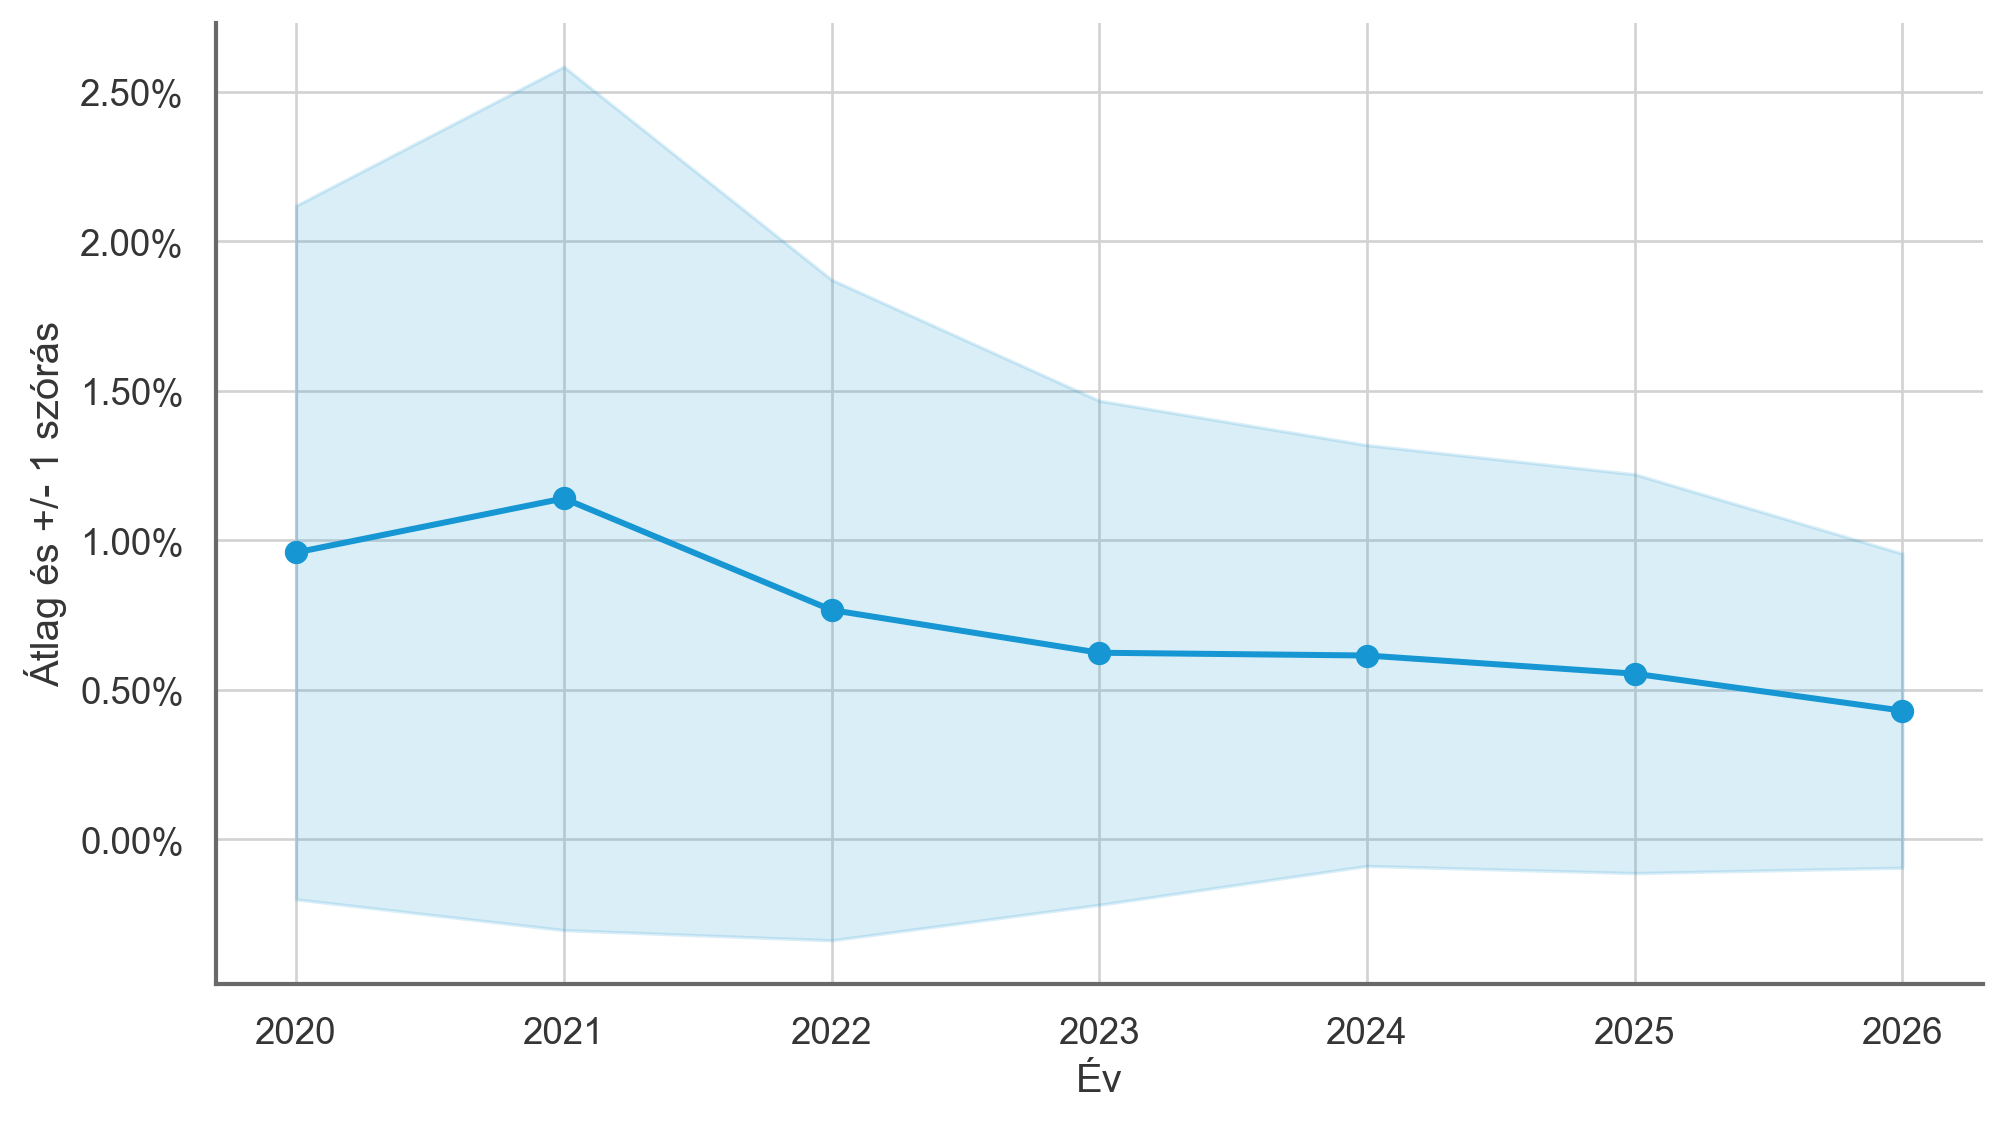

**Értelmezés:** nemcsak az átlag csökken, hanem a szórás is. A korai évek magasabb opportunity-levelt és szélesebb range-et mutatnak, mint 2024-2026.

In [5]:
#| label: fig-target-yearly-mean-std-band
#| fig-cap: "Éves target átlag és +/- 1 szórás sáv"
#| fig-alt: "Yearly mean long target with one standard deviation band."

fig, ax = plt.subplots(figsize=(9.5, 5.2))
band_df = yearly_df.copy()
ax.plot(band_df["year"], band_df["mean"], color=CQ_COLORS["blue"], linewidth=1.8, marker="o")
ax.fill_between(
    band_df["year"],
    band_df["mean"] - band_df["std"],
    band_df["mean"] + band_df["std"],
    color=CQ_COLORS["blue"],
    alpha=0.16,
)
ax.set_xlabel("Év")
ax.set_ylabel("Átlag és +/- 1 szórás")
ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=2))
plt.show()

display(Markdown(
    "**Értelmezés:** nemcsak az átlag csökken, hanem a szórás is. A korai évek magasabb opportunity-levelt és szélesebb range-et mutatnak, mint 2024-2026."
))


## Évek külön-külön és egymáson

**Mi ez.** Először külön panelen, utána egymásra rajzolva mutatjuk a havi target-profilokat.

**Forrás.** `target` tábla, havi átlagok év és hónap szerint.

**Értelmezés.** Ez segít eldönteni, hogy van-e visszatérő éves forma, vagy inkább rezsimdominált a target.


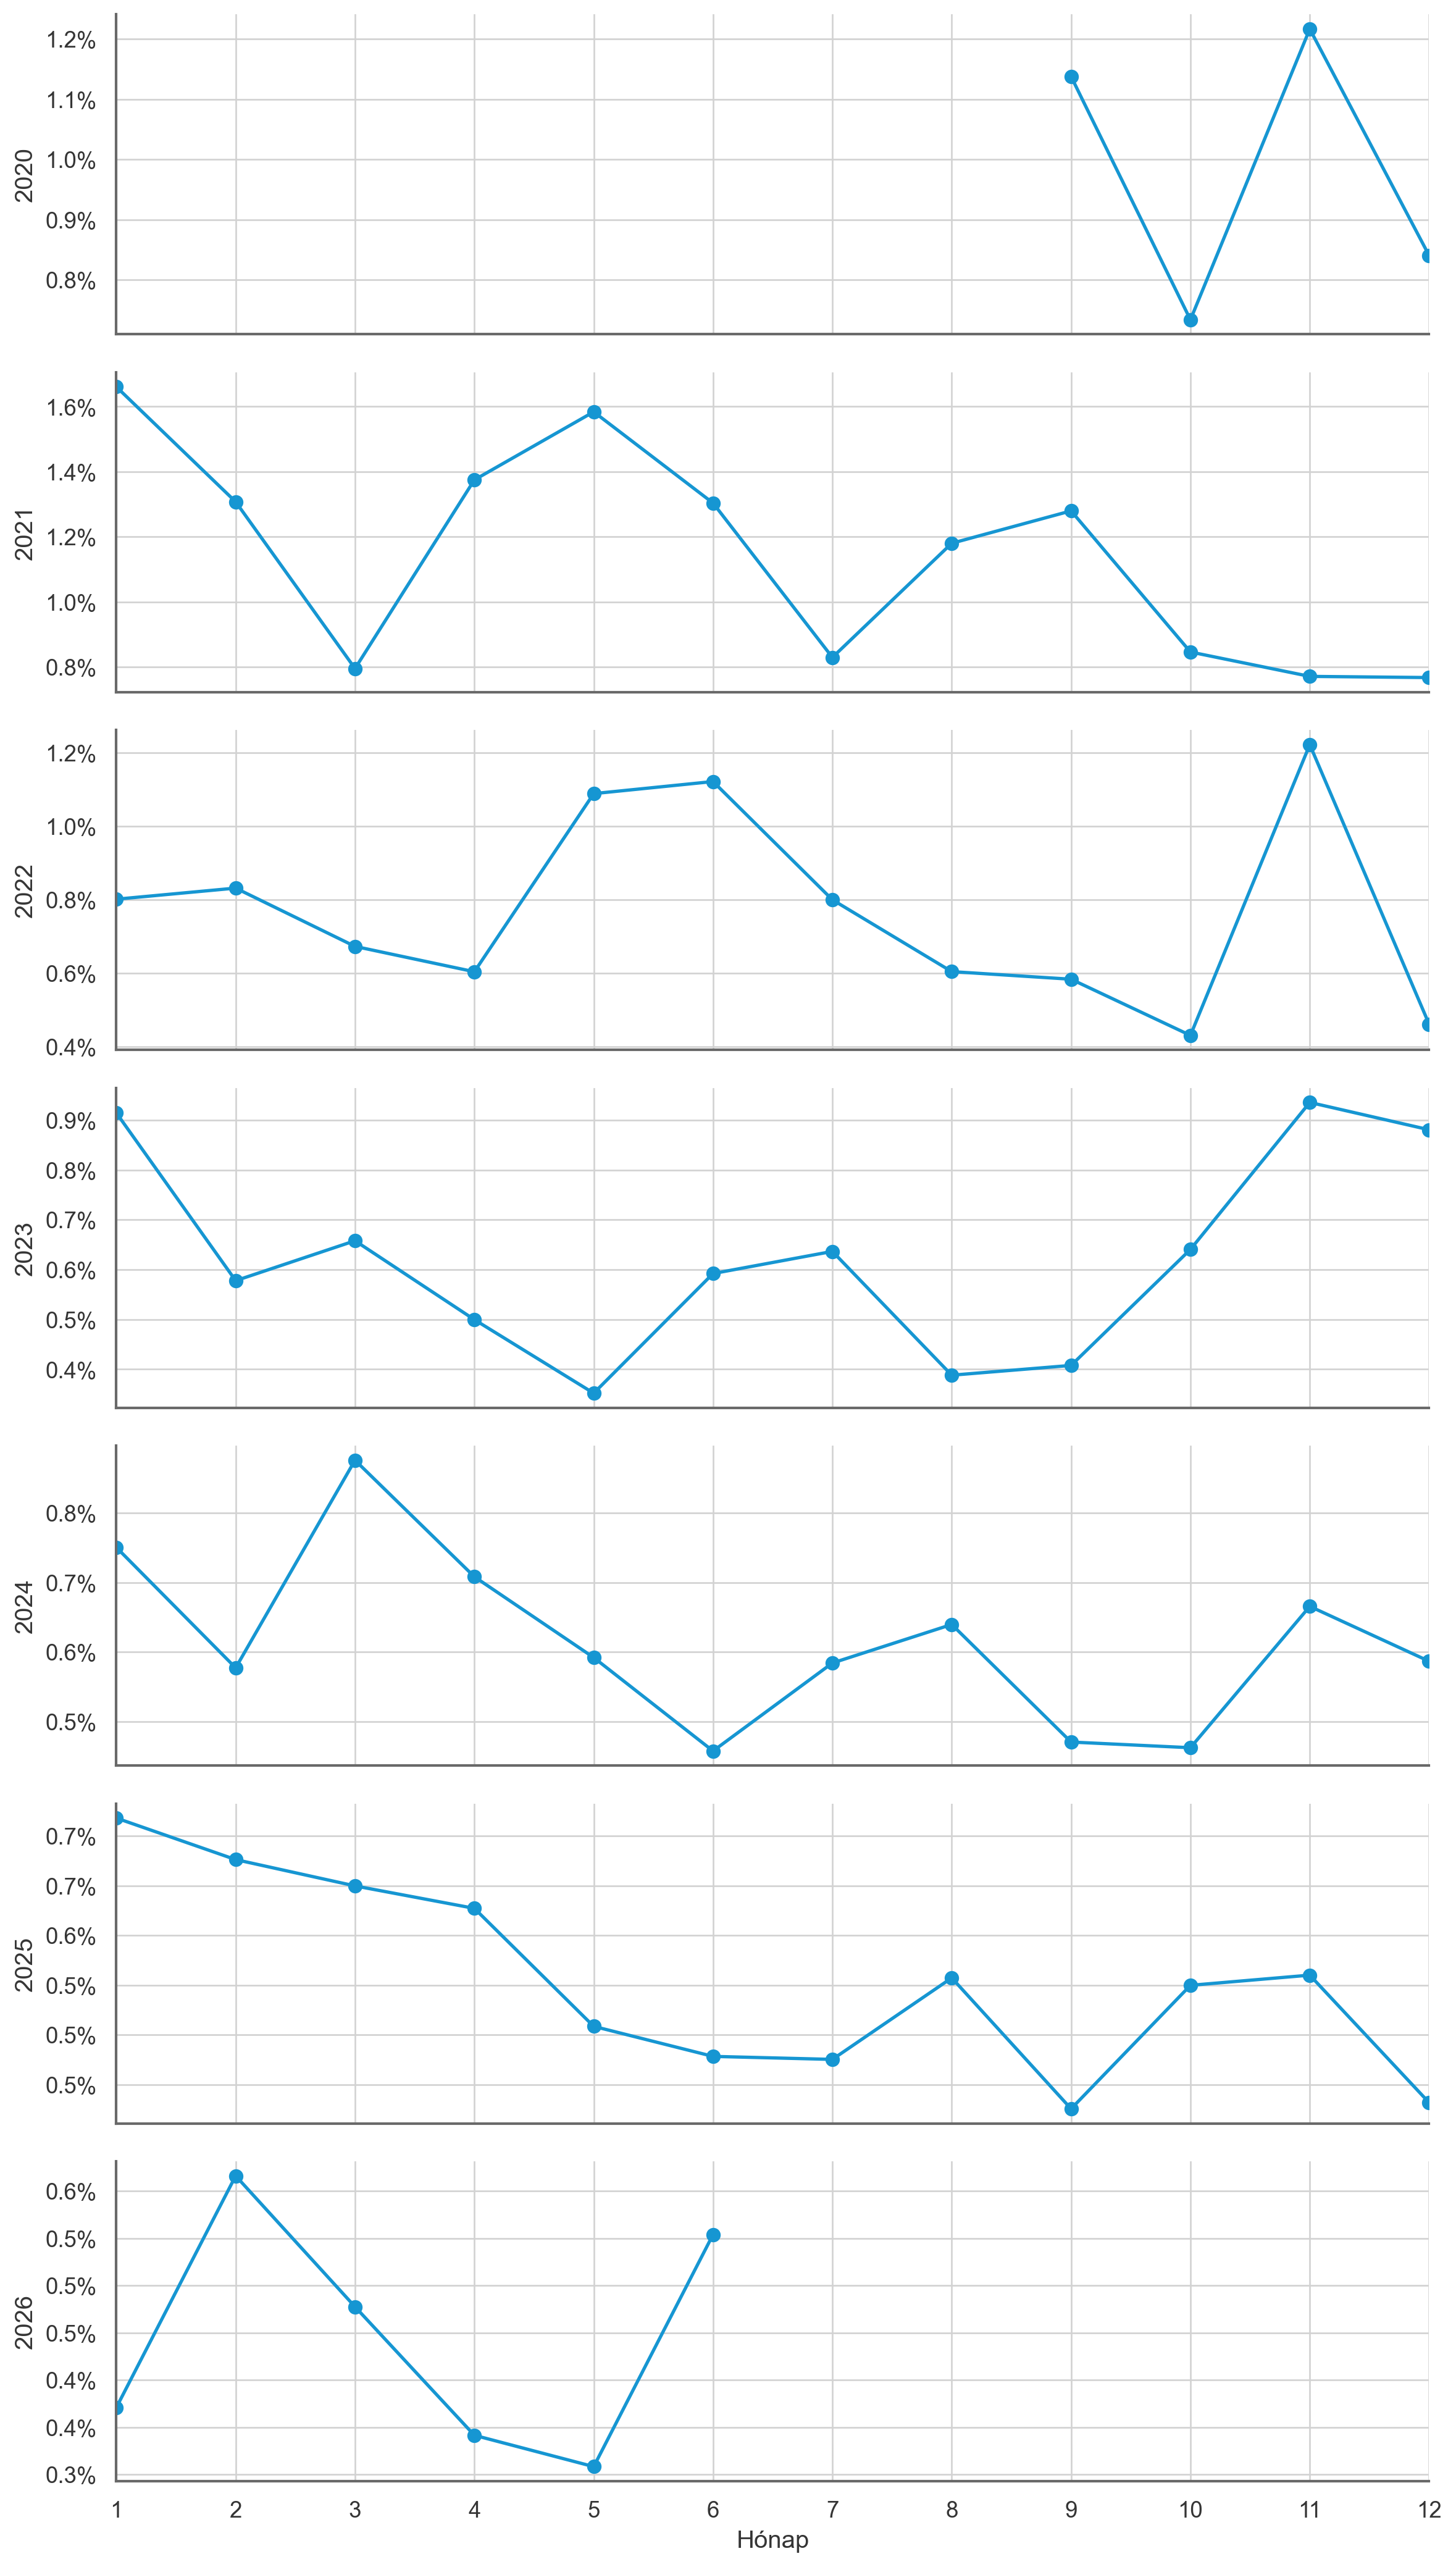

**Értelmezés:** a panelek alapján nincs egyetlen stabil, minden évben ismétlődő forma. A szinteltérés nagyobb, mint a közös szezonális alakzat ereje.

In [6]:
#| label: fig-target-monthly-profile-by-year-panels
#| fig-cap: "Havi target-profil külön panelen, évenként"
#| fig-alt: "Stacked monthly profile plots by year for the long target."

years = sorted(monthly_df["year"].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(10, 2.5 * len(years)), sharex=True)
if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    sub = monthly_df.loc[monthly_df["year"] == year]
    ax.plot(sub["month"], sub["mean"], color=CQ_COLORS["blue"], linewidth=1.6, marker="o")
    ax.set_ylabel(str(int(year)))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.set_xlim(1, 12)
    ax.set_xticks(range(1, 13))

axes[-1].set_xlabel("Hónap")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Értelmezés:** a panelek alapján nincs egyetlen stabil, minden évben ismétlődő forma. A szinteltérés nagyobb, mint a közös szezonális alakzat ereje."
))


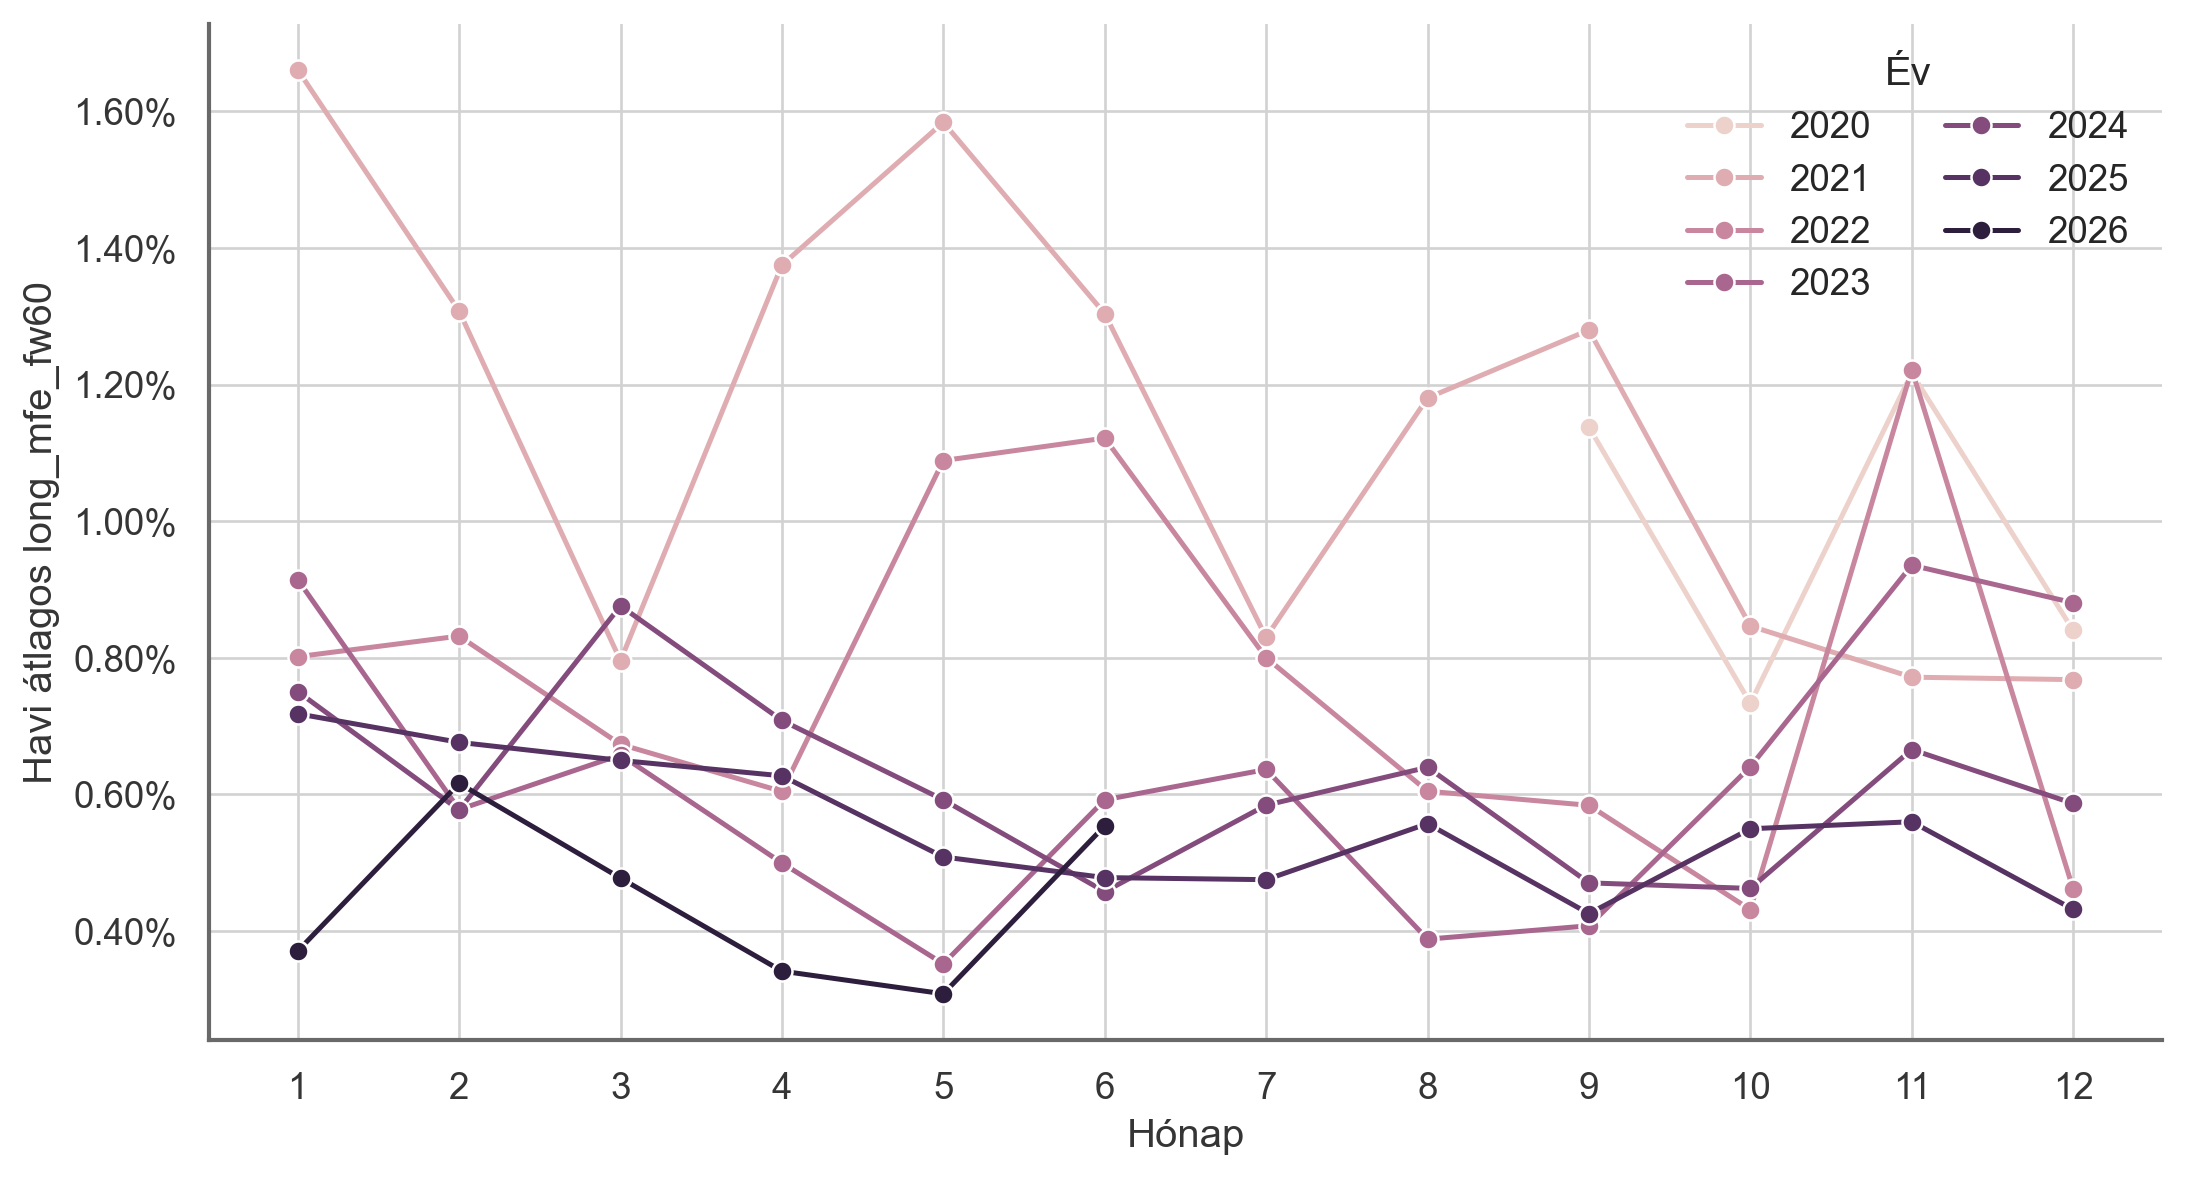

**Értelmezés:** az overlay alapján 2021 és 2020 magasabb target-szinten fut, míg 2025-2026 már egy jóval alacsonyabb rezsimben helyezkedik el.

In [7]:
#| label: fig-target-monthly-profile-overlay
#| fig-cap: "Havi target-profilok egymásra rajzolva"
#| fig-alt: "Overlay of yearly monthly long target profiles."

fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.lineplot(data=monthly_df, x="month", y="mean", hue="year", marker="o", ax=ax)
ax.set_xlabel("Hónap")
ax.set_ylabel("Havi átlagos long_mfe_fw60")
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=2))
ax.legend(title="Év", ncol=2)
plt.show()

display(Markdown(
    "**Értelmezés:** az overlay alapján 2021 és 2020 magasabb target-szinten fut, míg 2025-2026 már egy jóval alacsonyabb rezsimben helyezkedik el."
))


## Eloszlások éves összehasonlításban

**Mi ez.** Éves eloszlások vizuális és táblás összehasonlítása.

**Forrás.** `target` tábla, `long_mfe_fw60`; a vizuális boxplot hourly mintavételt használ, a táblás distance mutatók teljes adaton készülnek.

**Értelmezés.** Itt látszik, mely évek oszlanak el hasonlóan, és melyek térnek el jelentősen a többiektől.


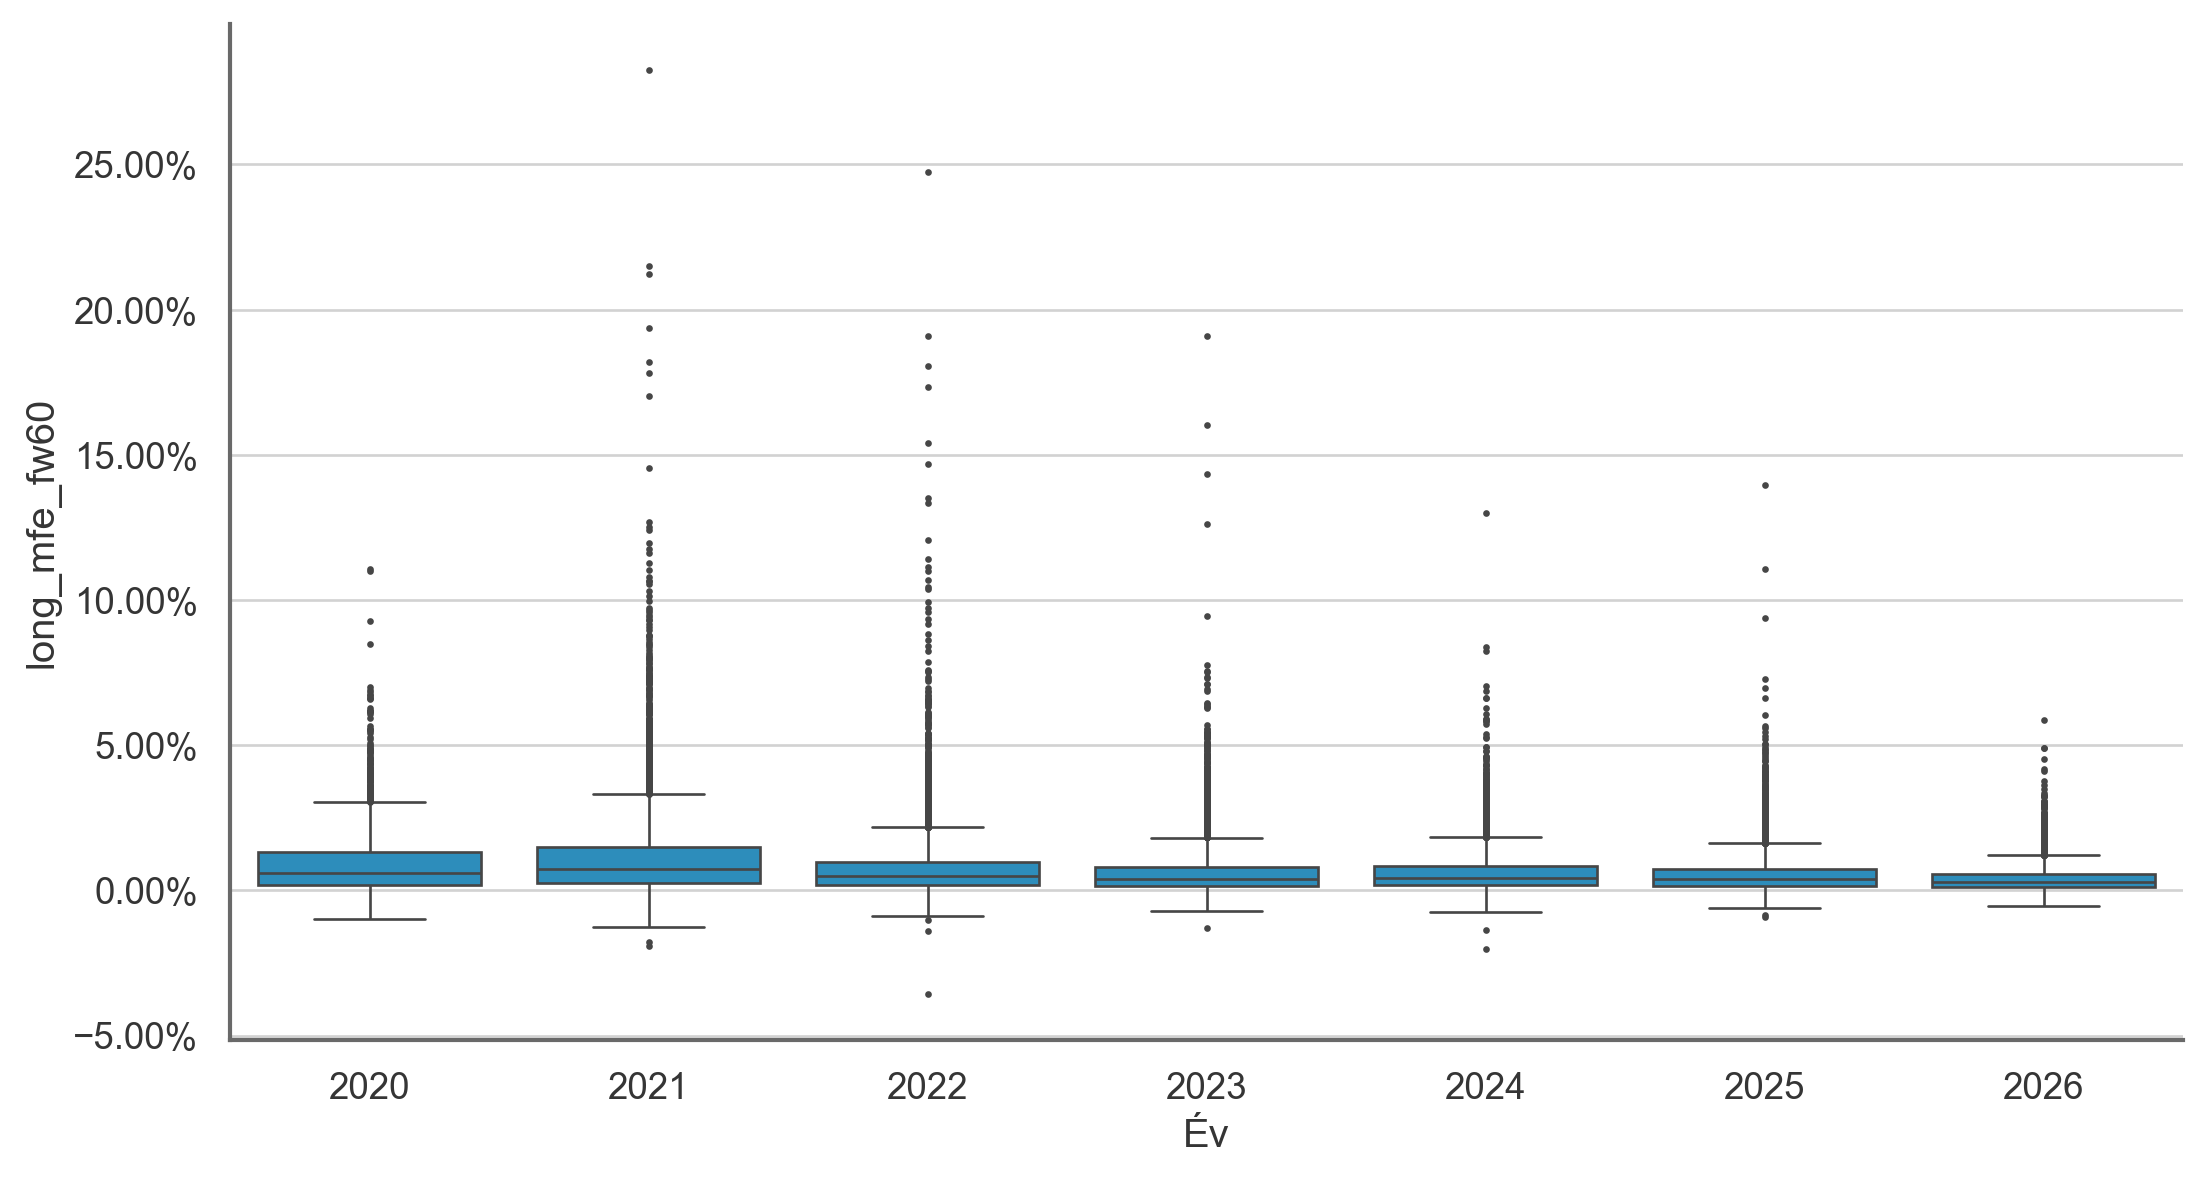

**Értelmezés:** a dobozok és whiskerek lefelé tolódnak az időben, vagyis nem csak a szélsőértékek, hanem a teljes éves eloszlás is elmozdul.

In [8]:
#| label: fig-target-distribution-boxplot-by-year
#| fig-cap: "Target eloszlások évenként, hourly mintavétellel"
#| fig-alt: "Boxplots of yearly long target distributions using hourly sampled observations."

fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.boxplot(data=hourly_plot_df, x="year", y=active_target, fliersize=1, linewidth=0.8, ax=ax)
ax.set_xlabel("Év")
ax.set_ylabel("long_mfe_fw60")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=2))
plt.show()

display(Markdown(
    "**Értelmezés:** a dobozok és whiskerek lefelé tolódnak az időben, vagyis nem csak a szélsőértékek, hanem a teljes éves eloszlás is elmozdul."
))


In [9]:
#| label: tbl-target-closest-year-pairs
#| tbl-cap: "A legközelebbi éves eloszlás-párok Wasserstein és KS szerint"

closest_pairs_df = distance_df.head(10).copy()
display_analysis_table(closest_pairs_df)

display(Markdown(
    "**Értelmezés:** a legközelebbi párok 2023-2024 és 2024-2025 körül jelennek meg. Ez arra utal, hogy a frissebb évek egymáshoz közelebb vannak, mint a korai rezsimekhez."
))


year1,year2,wasserstein,ks_stat
2023,2024,0.000,0.033
2024,2025,0.001,0.044
2023,2025,0.001,0.034
2025,2026,0.001,0.116
2022,2023,0.001,0.075
2022,2024,0.002,0.054
2020,2021,0.002,0.062
2024,2026,0.002,0.157
2023,2026,0.002,0.125
2022,2025,0.002,0.096


**Értelmezés:** a legközelebbi párok 2023-2024 és 2024-2025 körül jelennek meg. Ez arra utal, hogy a frissebb évek egymáshoz közelebb vannak, mint a korai rezsimekhez.

## Szezonalitás

**Mi ez.** Havi és negyedéves target-szezonális minta, az egyes évek saját átlagához viszonyítva.

**Forrás.** `target` tábla, havi és negyedéves aggregációk.

**Értelmezés.** Ha a szezonalitás erős és stabil, akkor a hónap vagy negyedév sokat segíthet a target viselkedésének értelmezésében. Ha a minta évenként széttart, akkor inkább rezsimhatásról beszélünk.


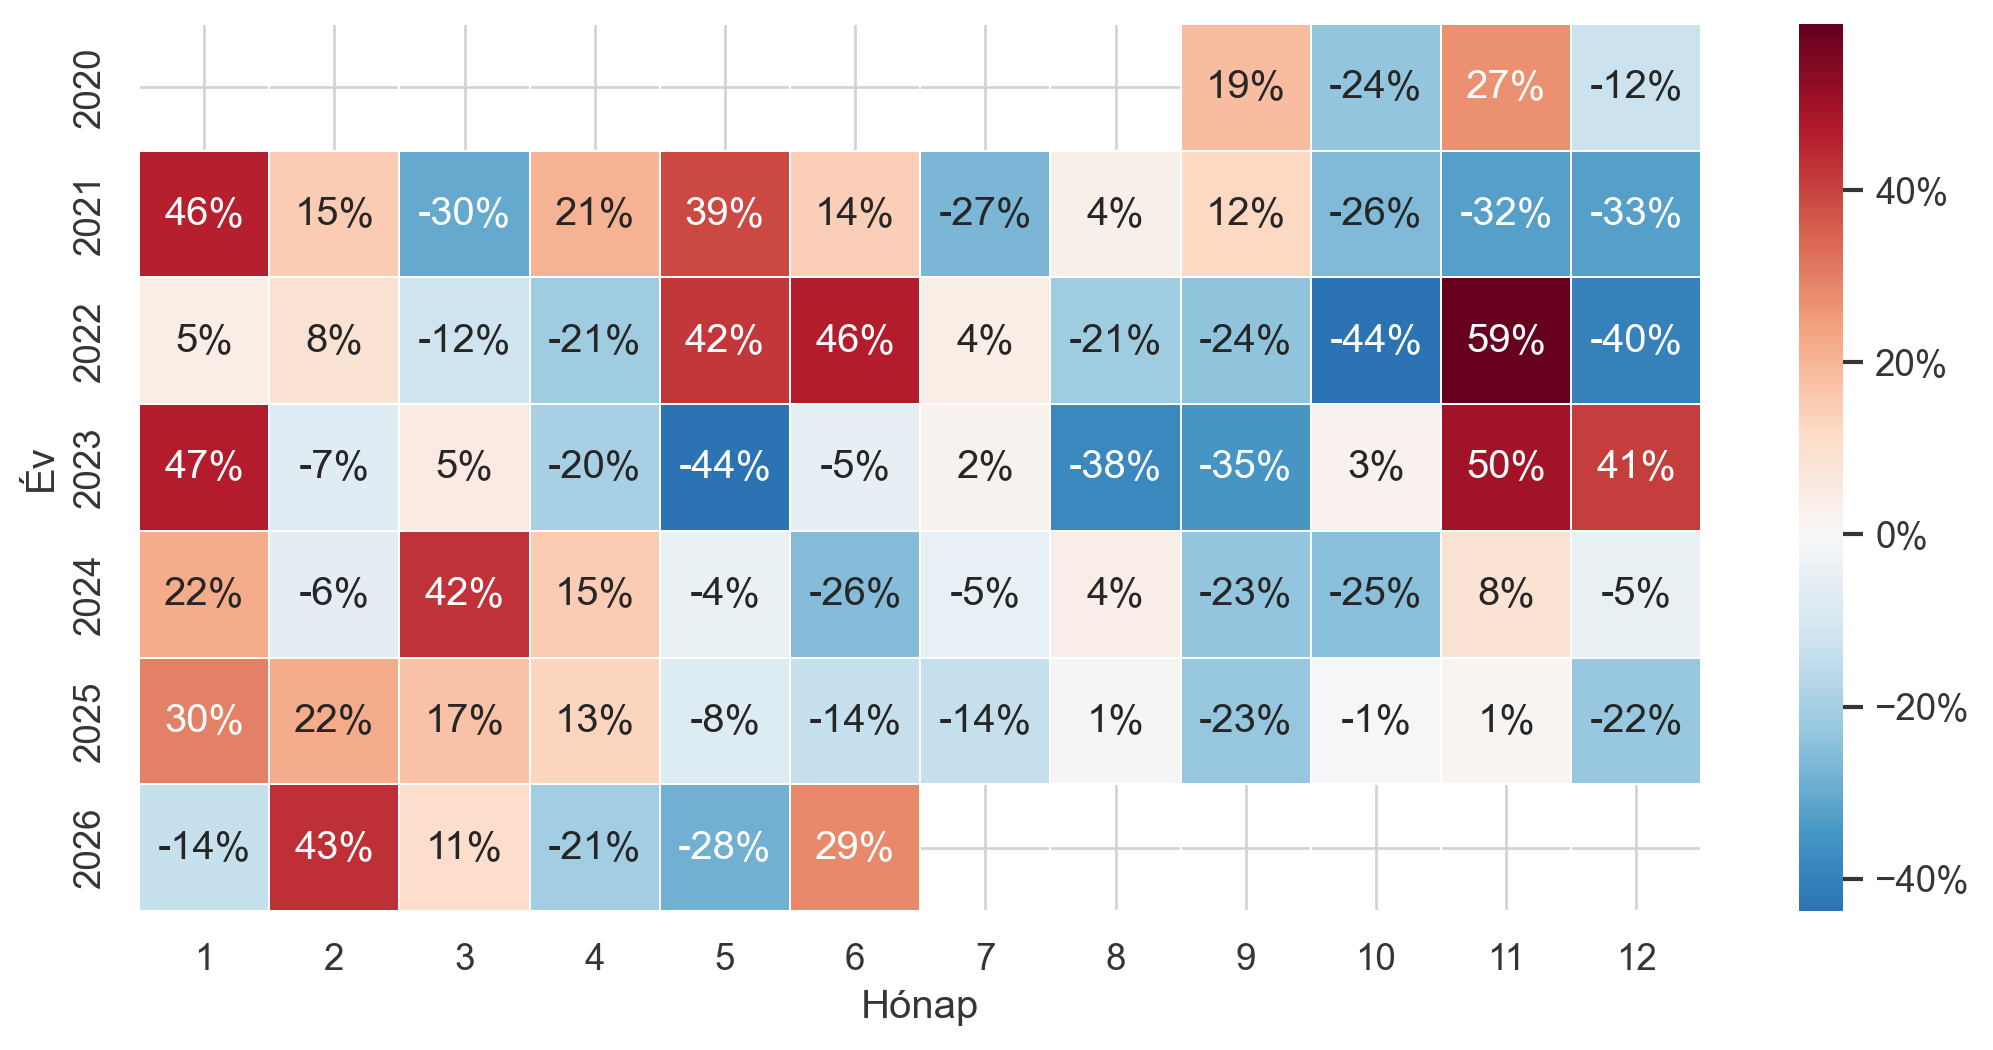

**Értelmezés:** néhány ismétlődő minta látszik, de a hónaphatás nem stabil minden évben. A szezonális jel jelen van, de gyengébb, mint az éves rezsimkülönbség.

In [10]:
#| label: fig-target-monthly-seasonality-heatmap
#| fig-cap: "Havi szezonális eltérés az adott év saját átlagához képest"
#| fig-alt: "Heatmap of monthly relative long target level versus each year's own mean."

heatmap_df = monthly_rel_df.pivot(index="year", columns="month", values="relative_to_year_mean")
fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.heatmap(
    heatmap_df,
    cmap="RdBu_r",
    center=0.0,
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    cbar_kws={"format": mtick.PercentFormatter(xmax=1.0, decimals=0)},
    ax=ax,
)
ax.set_xlabel("Hónap")
ax.set_ylabel("Év")
plt.show()

display(Markdown(
    "**Értelmezés:** néhány ismétlődő minta látszik, de a hónaphatás nem stabil minden évben. A szezonális jel jelen van, de gyengébb, mint az éves rezsimkülönbség."
))


quarter,mean,std,min,max,count
1,0.135,0.082,-0.000,0.230,6
2,0.003,0.196,-0.231,0.248,6
3,-0.071,0.142,-0.234,0.186,6
4,-0.043,0.198,-0.302,0.310,6


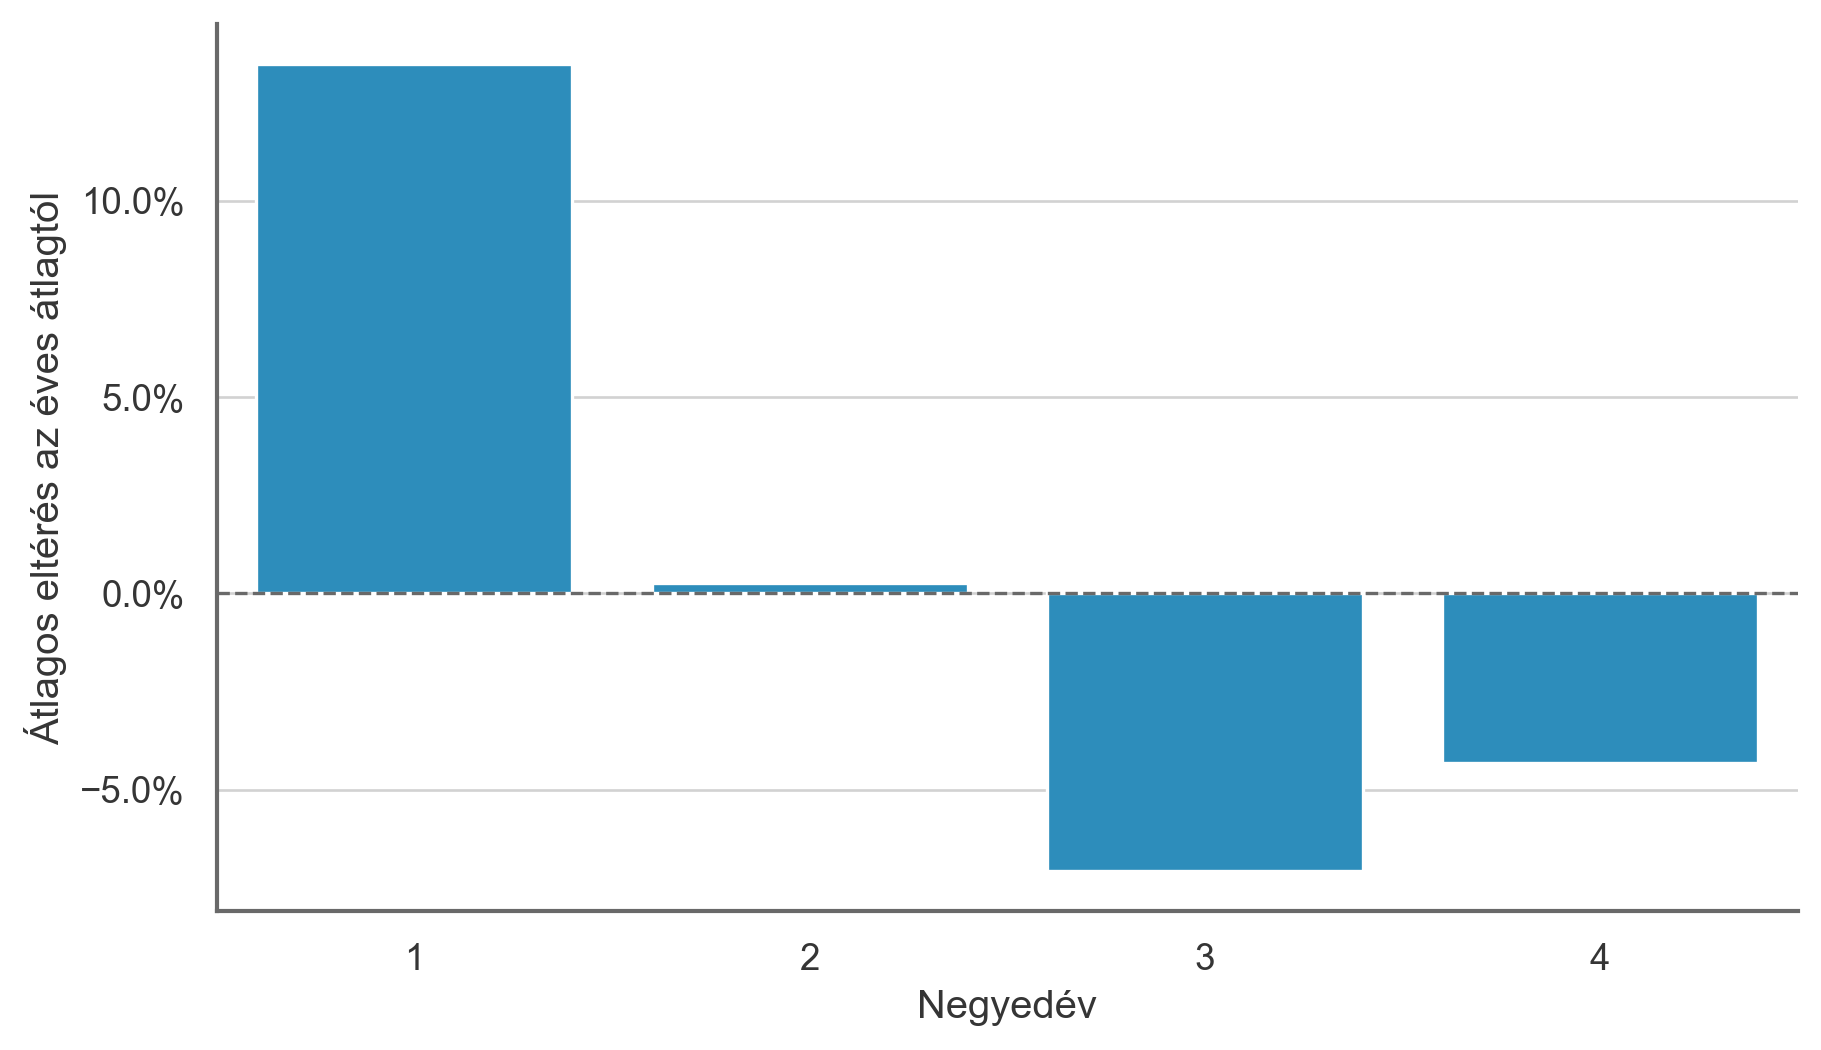

**Értelmezés:** átlagosan Q1 erősebb, Q3-Q4 gyengébb, de a szórás itt is nagy. Ez inkább puha szezonális minta, nem stabil szabály.

In [11]:
#| label: tbl-target-quarterly-seasonality-summary
#| tbl-cap: "Negyedéves szezonális eltérés az adott év saját átlagához képest"

display_analysis_table(quarterly_rel_summary_df)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(data=quarterly_rel_summary_df, x="quarter", y="mean", color=CQ_COLORS["blue"], ax=ax)
ax.axhline(0.0, color=CQ_COLORS["gray"], linestyle="--", linewidth=1)
ax.set_xlabel("Negyedév")
ax.set_ylabel("Átlagos eltérés az éves átlagtól")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
plt.show()

display(Markdown(
    "**Értelmezés:** átlagosan Q1 erősebb, Q3-Q4 gyengébb, de a szórás itt is nagy. Ez inkább puha szezonális minta, nem stabil szabály."
))


## 2026 összevetés és modellezési következmény

**Mi ez.** A 2026-os csonka év összevetése azonos január 1. - június 14. közötti korábbi szakaszokkal, majd ebből gyakorlati javaslat a modellfejlesztéshez.

**Forrás.** `target` tábla, `long_mfe_fw60`; az összehasonlítás a 2026-06-14-ig elérhető időablakra vágott korábbi évekkel történik.

**Értelmezés.** Ez a legfontosabb blokk a kalibrációhoz: mely évek hasonlók 2026-hoz, és melyeket kell inkább csak háttérinformációként kezelni.


In [12]:
#| label: tbl-target-same-span-vs-2026
#| tbl-cap: "Azonos időablakú összevetés a 2026-06-14-ig tartó szakaszhoz"

display_analysis_table(same_span_df)

nearest_year = int(
    same_span_df.loc[same_span_df["year"] != latest_year]
    .sort_values("vs_latest_wasserstein")
    .iloc[0]["year"]
)
farthest_year = int(
    same_span_df.loc[same_span_df["year"] != latest_year]
    .sort_values("vs_latest_wasserstein", ascending=False)
    .iloc[0]["year"]
)
display(Markdown(
    f"**Értelmezés:** a 2026-os csonka évhez a legközelebbi azonos-span év `{nearest_year}`, a legtávolabbi `{farthest_year}`. "
    "A 2021-es és részben a 2022-es target-szint lényegesen magasabb a mai rezsimnél."
))


year,rows,mean,std,median,p95,p99,vs_latest_mean_diff,vs_latest_wasserstein,vs_latest_ks_stat
2021,237600,0.013,0.017,0.008,0.044,0.078,-0.009,0.009,0.377
2022,237600,0.008,0.010,0.005,0.026,0.048,-0.004,0.004,0.241
2023,237600,0.006,0.009,0.004,0.019,0.037,-0.002,0.002,0.105
2024,239040,0.007,0.008,0.005,0.021,0.037,-0.002,0.002,0.184
2025,237600,0.006,0.008,0.004,0.019,0.035,-0.002,0.002,0.155
2026,236821,0.004,0.005,0.003,0.014,0.025,0.000,0.000,0.000


**Értelmezés:** a 2026-os csonka évhez a legközelebbi azonos-span év `2023`, a legtávolabbi `2021`. A 2021-es és részben a 2022-es target-szint lényegesen magasabb a mai rezsimnél.

In [13]:
#| label: tbl-target-monthly-profile-corr-vs-2026
#| tbl-cap: "A 2026-os havi profil korrelációja a korábbi évekkel"

display_analysis_table(profile_corr_df)

display(Markdown(
    "**Értelmezés:** a havi alakzat korrelációja sem túl erős, ezért a 2026-os viselkedést nem egy erős, ismétlődő szezonális profil, hanem inkább egy alacsonyabb opportunity-rezsim írja le."
))


year,common_months,corr_with_latest
2023,6,0.157
2022,6,0.130
2025,6,0.040
2024,6,-0.344
2021,6,-0.466
2020,0,—


**Értelmezés:** a havi alakzat korrelációja sem túl erős, ezért a 2026-os viselkedést nem egy erős, ismétlődő szezonális profil, hanem inkább egy alacsonyabb opportunity-rezsim írja le.

In [14]:
#| label: tbl-target-modeling-implications
#| tbl-cap: "Modellezési és kalibrációs következmények"

recommendation_lines = h.recommendation_lines(same_span_df, profile_corr_df)
bullet_md = "\n".join(f"- {line}" for line in recommendation_lines)

display(Markdown(
    "**Modellezési olvasat**\n\n"
    "A target viselkedése alapján az évek nem tekinthetők teljesen egységesnek. "
    "A korai évek magasabb átlagot és nagyobb szórást mutatnak, a 2023-2026 blokk pedig alacsonyabb, egymáshoz közelebb álló rezsimet képvisel.\n\n"
    "**Gyakorlati javaslat:**\n"
    f"{bullet_md}\n\n"
    "**Döntési irány:** a teljes history nem kizárandó, de nem is szabad úgy kezelni, mintha minden év azonos target-regime lenne. "
    "Tanításhoz expanding-window + recency-aware validáció indokolt; 2026-os kalibrációhoz elsődleges referencia a 2023-2025 blokk, különösen 2025."
))


**Modellezési olvasat**

A target viselkedése alapján az évek nem tekinthetők teljesen egységesnek. A korai évek magasabb átlagot és nagyobb szórást mutatnak, a 2023-2026 blokk pedig alacsonyabb, egymáshoz közelebb álló rezsimet képvisel.

**Gyakorlati javaslat:**
- A 2026-os target szintje a legközelebb ezekhez az évekhez áll: 2023, 2025, 2024.
- A legtávolabbi rezsimek a 2021, 2022 évek, ezeket azonos súllyal kezelni torzíthatja a kalibrációt.
- A havi profil hasonlóság alapján a legközelebbi minták: 2023, 2022.
- A teljes history megtartható expanding-window tanításhoz, de a kalibrációt és a döntési küszöböket recency-aware módon érdemes hangolni.

**Döntési irány:** a teljes history nem kizárandó, de nem is szabad úgy kezelni, mintha minden év azonos target-regime lenne. Tanításhoz expanding-window + recency-aware validáció indokolt; 2026-os kalibrációhoz elsődleges referencia a 2023-2025 blokk, különösen 2025.